## Download Dataset from Kaggle

To download datasets from Kaggle using the API, you need to set up your Kaggle API credentials.

1.  **Generate Kaggle API Key**: Go to your Kaggle account profile (kaggle.com/your-username/account), scroll down to the 'API' section, and click 'Create New API Token'. This will download `kaggle.json` file.
2.  **Upload `kaggle.json`**: In Google Colab, click on the folder icon on the left sidebar to open the 'Files' tab. Then, upload your `kaggle.json` file into the `/root/.kaggle/` directory. If the `.kaggle` directory doesn't exist, you'll need to create it first.
3.  **Secure your API key**: It is recommended to add your API key to Colab's secrets manager for better security and easier access across sessions.

Once `kaggle.json` is in place, you can proceed with the following steps.

In [17]:
# Install the Kaggle library
!pip install kaggle

In [18]:
import os

# Create .kaggle directory if it doesn't exist
if not os.path.exists('/root/.kaggle'):
    os.makedirs('/root/.kaggle')

# Move kaggle.json to the correct directory (assuming it's already uploaded to the root of your Colab files)
# If you uploaded it to /content/, you'll need to adjust the path.
# Make sure kaggle.json has the correct permissions
!chmod 600 /root/.kaggle/kaggle.json

# Download the dataset
# The dataset URL is: https://www.kaggle.com/datasets/pkdarabi/cardetection
# The command is: kaggle datasets download -d pkdarabi/cardetection
!kaggle datasets download -d pkdarabi/cardetection

chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/pkdarabi/cardetection
License(s): Attribution 4.0 International (CC BY 4.0)
cardetection.zip: Skipping, found more recently modified local copy (use --force to force download)


In [19]:
import zipfile
import os

# Unzipping the downloaded dataset
zip_file_name = 'cardetection.zip' # Kaggle usually names the downloaded file after the dataset

if os.path.exists(zip_file_name):
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall('cardetection_dataset') # Extract to a new directory
    print(f"'{zip_file_name}' extracted to 'cardetection_dataset/'")
else:
    print(f"Error: '{zip_file_name}' not found. Please ensure the download was successful.")

# Listing the contents of the extracted directory to verify
!ls cardetection_dataset

'cardetection.zip' extracted to 'cardetection_dataset/'
car  video.mp4


## Validate Annotations (YOLO Format)

Before proceeding, it's crucial to ensure that the annotation files are correctly formatted according to the YOLO specification: `class_id cx cy w h`, where `class_id` is an integer and `cx`, `cy`, `w`, `h` are floating-point numbers normalized between 0 and 1. Each line in an annotation file corresponds to one object detection.

First, let's find a few annotation files to inspect. We'll look for `.txt` files in the `cardetection_dataset` directory.

In [20]:
import os

def find_annotation_files(base_dir, num_samples=5):
    annotation_files = []
    for root, _, files in os.walk(base_dir):
        for file in files:
            if file.endswith('.txt'): # YOLO annotations are typically .txt files
                annotation_files.append(os.path.join(root, file))
                if len(annotation_files) >= num_samples:
                    return annotation_files
    return annotation_files

# Assuming 'cardetection_dataset' is the root of the extracted data
DATASET_ROOT = 'cardetection_dataset'

sample_annotation_paths = find_annotation_files(DATASET_ROOT, num_samples=10)

print(f"Found {len(sample_annotation_paths)} sample annotation files:")
for path in sample_annotation_paths:
    print(path)

Found 10 sample annotation files:
cardetection_dataset/car/README.roboflow.txt
cardetection_dataset/car/README.dataset.txt
cardetection_dataset/car/test/labels/001472_jpg.rf.38654b39e5bc13159c16952df2ba2dc0.txt
cardetection_dataset/car/test/labels/000295_jpg.rf.3940d624bf6e15926480dad000dd8fa4.txt
cardetection_dataset/car/test/labels/00001_00066_00015_png.rf.e1adfeb91011dcf5d548147d1acc30eb.txt
cardetection_dataset/car/test/labels/FisheyeCamera_1_00509_png.rf.a4fdcf5053bc422a3b30b4cef69e5ea6.txt
cardetection_dataset/car/test/labels/00004_00038_00016_png.rf.91ed21fee2978def3dd315ee735fc1c0.txt
cardetection_dataset/car/test/labels/001654_JPG_jpg.rf.e26100131533da63b018a72fab6586e3.txt
cardetection_dataset/car/test/labels/00003_00010_00012_png.rf.992b5dc958856171d8218c027b672b12.txt
cardetection_dataset/car/test/labels/road470_png.rf.7670afafae0b681bed4d7bd1ce2f1775.txt


Next, we'll implement a function to validate the content of these annotation files.

In [21]:
def validate_yolo_annotation(file_path):
    errors = []
    try:
        with open(file_path, 'r') as f:
            for i, line in enumerate(f, 1):
                parts = line.strip().split()
                if len(parts) != 5:
                    errors.append(f"Line {i}: Expected 5 values, got {len(parts)}.\n")
                    continue

                try:
                    class_id = int(parts[0])
                except ValueError:
                    errors.append(f"Line {i}: class_id '{parts[0]}' is not an integer.\n")

                try:
                    coords = [float(p) for p in parts[1:]]
                    for j, coord in enumerate(coords):
                        if not (0.0 <= coord <= 1.0):
                            errors.append(f"Line {i}: Coordinate '{parts[j+1]}' (value: {coord}) is not normalized (0-1).\n")
                except ValueError:
                    errors.append(f"Line {i}: One or more coordinates are not valid floats.\n")

    except FileNotFoundError:
        errors.append(f"File not found: {file_path}\n")
    except Exception as e:
        errors.append(f"An unexpected error occurred while reading {file_path}: {e}\n")

    return len(errors) == 0, errors


print("\n--- Running Annotation Validation ---")
validation_results = {}
for anno_path in sample_annotation_paths:
    is_valid, errs = validate_yolo_annotation(anno_path)
    validation_results[anno_path] = (is_valid, errs)

    if is_valid:
        print(f"[VALID] {anno_path}")
    else:
        print(f"[INVALID] {anno_path}:")
        for err in errs:
            print(f"  - {err.strip()}")

print("\n--- Validation Summary ---")
num_valid = sum(1 for is_valid, _ in validation_results.values() if is_valid)
num_invalid = len(validation_results) - num_valid

print(f"Total files checked: {len(validation_results)}")
print(f"Valid files: {num_valid}")
print(f"Invalid files: {num_invalid}")

if num_invalid > 0:
    print("Please review the invalid files and correct their formatting.")


--- Running Annotation Validation ---
[INVALID] cardetection_dataset/car/README.roboflow.txt:
  - Line 1: Expected 5 values, got 0.
  - Line 2: Expected 5 values, got 10.
  - Line 3: Expected 5 values, got 1.
  - Line 4: Expected 5 values, got 0.
  - Line 5: Expected 5 values, got 14.
  - Line 6: Expected 5 values, got 0.
  - Line 7: Expected 5 values, got 10.
  - Line 8: Expected 5 values, got 9.
  - Line 9: class_id '*' is not an integer.
  - Line 9: One or more coordinates are not valid floats.
  - Line 10: Expected 5 values, got 7.
  - Line 11: class_id '*' is not an integer.
  - Line 11: One or more coordinates are not valid floats.
  - Line 12: Expected 5 values, got 8.
  - Line 13: Expected 5 values, got 10.
  - Line 14: Expected 5 values, got 0.
  - Line 15: Expected 5 values, got 15.
  - Line 16: Expected 5 values, got 2.
  - Line 17: Expected 5 values, got 0.
  - Line 18: Expected 5 values, got 11.
  - Line 19: Expected 5 values, got 0.
  - Line 20: class_id 'The' is not an 

## Script to Automatically Fix Annotation Files

This script will attempt to automatically fix common formatting errors in YOLO annotation files. It will:

*   Convert `class_id` to an integer if it's a float string (e.g., "0.0" to "0").
*   Convert `cx`, `cy`, `w`, `h` to floats if they are integer strings (e.g., "0" to "0.0").
*   **Skip (remove) lines** that do not have exactly 5 values.
*   **Skip (remove) lines** where `class_id` or coordinates are non-numeric and cannot be converted.
*   **Skip (remove) lines** where `cx`, `cy`, `w`, `h` are outside the `0.0` to `1.0` range. Correcting these typically requires the corresponding image dimensions, which are not available in the annotation file itself.

For safety, a backup of each modified annotation file will be created with a `.bak` extension.

In [22]:
import os
import shutil

# Helper function to get all annotation files (not just samples)
def get_all_annotation_files(base_dir):
    all_annotation_files = []
    for root, _, files in os.walk(base_dir):
        for file in files:
            if file.endswith('.txt'): # Assuming YOLO annotations are .txt files
                all_annotation_files.append(os.path.join(root, file))
    return all_annotation_files

# Function to fix a single YOLO annotation line
def fix_yolo_line(line_content):
    original_line = line_content.strip()
    parts = original_line.split()

    if len(parts) != 5:
        return None, f"Skipped: Incorrect number of values (expected 5, got {len(parts)})"

    fixed_parts = []
    # Attempt to fix class_id
    try:
        class_id = int(float(parts[0])) # Try converting float to int (e.g., '0.0' to 0)
        fixed_parts.append(str(class_id))
    except ValueError:
        return None, f"Skipped: Invalid class_id '{parts[0]}'"

    # Attempt to fix coordinates and check normalization
    for i in range(1, 5):
        try:
            coord = float(parts[i])
            if not (0.0 <= coord <= 1.0):
                return None, f"Skipped: Coordinate '{parts[i]}' ({coord}) not normalized (0-1)"
            fixed_parts.append(f"{coord:.6f}") # Format to 6 decimal places for consistency
        except ValueError:
            return None, f"Skipped: Invalid coordinate '{parts[i]}'"

    return ' '.join(fixed_parts) + '\n', "Fixed"


# Get all annotation files within the dataset root
all_annotation_paths = get_all_annotation_files(DATASET_ROOT)

print(f"Found {len(all_annotation_paths)} annotation files to check/fix.")
print("\n--- Attempting to fix annotation files ---")

fixed_files_count = 0
partially_fixed_files_count = 0
problematic_files_count = 0

for file_path in all_annotation_paths:
    original_lines = []
    fixed_lines = []
    skipped_lines_count = 0
    total_lines = 0

    try:
        with open(file_path, 'r') as f:
            original_lines = f.readlines()
            total_lines = len(original_lines)

        for line in original_lines:
            fixed_line, status_message = fix_yolo_line(line)
            if fixed_line is not None:
                fixed_lines.append(fixed_line)
            else:
                skipped_lines_count += 1
                # Optional: print skipped line details
                # print(f"  - {file_path}: {status_message} - Original line: '{line.strip()}'")

        if skipped_lines_count > 0 or len(fixed_lines) != total_lines:
            # Only create a backup and write if changes were made or lines were skipped
            backup_path = file_path + '.bak'
            shutil.copyfile(file_path, backup_path)

            with open(file_path, 'w') as f:
                f.writelines(fixed_lines)

            if skipped_lines_count == total_lines:
                print(f"[ERROR] {file_path}: All {total_lines} lines skipped. (Backup created: {backup_path})")
                problematic_files_count += 1
            elif skipped_lines_count > 0:
                print(f"[PARTIALLY FIXED] {file_path}: {total_lines - skipped_lines_count} lines fixed, {skipped_lines_count} lines skipped. (Backup created: {backup_path})")
                partially_fixed_files_count += 1
            else:
                print(f"[FIXED] {file_path}: {total_lines} lines fixed. (Backup created: {backup_path})")
                fixed_files_count += 1
        else:
            print(f"[OK] {file_path}: No issues found or no changes needed.")

    except FileNotFoundError:
        print(f"[ERROR] File not found: {file_path}")
        problematic_files_count += 1
    except Exception as e:
        print(f"[ERROR] An unexpected error occurred with {file_path}: {e}")
        problematic_files_count += 1

print("\n--- Annotation Fixing Summary ---")
print(f"Total files processed: {len(all_annotation_paths)}")
print(f"Files fully fixed: {fixed_files_count}")
print(f"Files partially fixed (some lines skipped): {partially_fixed_files_count}")
print(f"Files with unfixable issues (all lines skipped or other errors): {problematic_files_count}")
print("Original files are backed up with a '.bak' extension.")

Found 4971 annotation files to check/fix.

--- Attempting to fix annotation files ---
[ERROR] cardetection_dataset/car/README.roboflow.txt: All 28 lines skipped. (Backup created: cardetection_dataset/car/README.roboflow.txt.bak)
[ERROR] cardetection_dataset/car/README.dataset.txt: All 6 lines skipped. (Backup created: cardetection_dataset/car/README.dataset.txt.bak)
[OK] cardetection_dataset/car/test/labels/001472_jpg.rf.38654b39e5bc13159c16952df2ba2dc0.txt: No issues found or no changes needed.
[OK] cardetection_dataset/car/test/labels/000295_jpg.rf.3940d624bf6e15926480dad000dd8fa4.txt: No issues found or no changes needed.
[OK] cardetection_dataset/car/test/labels/00001_00066_00015_png.rf.e1adfeb91011dcf5d548147d1acc30eb.txt: No issues found or no changes needed.
[OK] cardetection_dataset/car/test/labels/FisheyeCamera_1_00509_png.rf.a4fdcf5053bc422a3b30b4cef69e5ea6.txt: No issues found or no changes needed.
[OK] cardetection_dataset/car/test/labels/00004_00038_00016_png.rf.91ed21fee2

## Organize Directory Structure

Now, let's organize the dataset into the specified YOLO format directory structure:

*   `dataset/images/train/`
*   `dataset/images/val/`
*   `dataset/images/test/`
*   `dataset/labels/train/`
*   `dataset/labels/val/`
*   `dataset/labels/test/`

This script will create these directories, then find all image and corresponding label files. It will then split these pairs into training, validation, and test sets (e.g., 80/10/10 split) and move them to their designated folders. It assumes image and label files share the same base name (e.g., `image.jpg` and `image.txt`).

In [23]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define the base directory for the new organized dataset
OUTPUT_BASE_DIR = 'dataset'

# Define the new directory structure paths
IMG_TRAIN_DIR = os.path.join(OUTPUT_BASE_DIR, 'images', 'train')
IMG_VAL_DIR = os.path.join(OUTPUT_BASE_DIR, 'images', 'val')
IMG_TEST_DIR = os.path.join(OUTPUT_BASE_DIR, 'images', 'test')

LAB_TRAIN_DIR = os.path.join(OUTPUT_BASE_DIR, 'labels', 'train')
LAB_VAL_DIR = os.path.join(OUTPUT_BASE_DIR, 'labels', 'val')
LAB_TEST_DIR = os.path.join(OUTPUT_BASE_DIR, 'labels', 'test')

# Create all necessary directories
for path in [IMG_TRAIN_DIR, IMG_VAL_DIR, IMG_TEST_DIR, LAB_TRAIN_DIR, LAB_VAL_DIR, LAB_TEST_DIR]:
    os.makedirs(path, exist_ok=True)
    print(f"Created directory: {path}")

# --- Gather all image and label paths ---

all_image_paths = []
all_label_paths = []

# This map will store basename -> (image_path, label_path if found)
file_map = {}

# First, find all image files and store them by their basename
for root, _, files in os.walk(DATASET_ROOT):
    for file in files:
        basename, ext = os.path.splitext(file)
        if ext.lower() in ['.jpg', '.jpeg', '.png']:
            if basename not in file_map:
                file_map[basename] = {'image': None, 'label': None}
            file_map[basename]['image'] = os.path.join(root, file)

# Now, find all label files and link them to images by basename
for root, _, files in os.walk(DATASET_ROOT):
    for file in files:
        basename, ext = os.path.splitext(file)
        if ext.lower() == '.txt':
            if basename not in file_map:
                file_map[basename] = {'image': None, 'label': None}
            file_map[basename]['label'] = os.path.join(root, file)

# Filter for complete image-label pairs
for basename, paths in file_map.items():
    if paths['image'] and paths['label']:
        all_image_paths.append(paths['image'])
        all_label_paths.append(paths['label'])
    elif paths['image']:
        print(f"Warning: No corresponding label found for image: {paths['image']}. Skipping.")
    elif paths['label']:
        print(f"Warning: No corresponding image found for label: {paths['label']}. Skipping.")

print(f"Found {len(all_image_paths)} image-label pairs for splitting.")

if not all_image_paths:
    print("Error: No image-label pairs found. Please check `DATASET_ROOT` and the file scanning logic.")
else:
    # --- Split the data into training, validation, and test sets ---
    # Using a 80/10/10 split (train/val/test)

    # First split: 80% train, 20% (val+test)
    train_images, val_test_images, train_labels, val_test_labels = train_test_split(
        all_image_paths, all_label_paths, test_size=0.2, random_state=42
    )

    # Second split: 50% val, 50% test from the val_test_set (which is 20% of total, so 10% each)
    val_images, test_images, val_labels, test_labels = train_test_split(
        val_test_images, val_test_labels, test_size=0.5, random_state=42
    )

    print(f"\nDataset split ratios:")
    print(f"  Train: {len(train_images)} images")
    print(f"  Validation: {len(val_images)} images")
    print(f"  Test: {len(test_images)} images")

    # --- Function to move files ---
    def move_files(file_paths, destination_dir):
        for src_path in file_paths:
            dst_path = os.path.join(destination_dir, os.path.basename(src_path))
            shutil.move(src_path, dst_path)

    print("\nMoving files to new directory structure...")

    # Move training files
    move_files(train_images, IMG_TRAIN_DIR)
    move_files(train_labels, LAB_TRAIN_DIR)
    print(f"Moved {len(train_images)} training images and labels.")

    # Move validation files
    move_files(val_images, IMG_VAL_DIR)
    move_files(val_labels, LAB_VAL_DIR)
    print(f"Moved {len(val_images)} validation images and labels.")

    # Move test files
    move_files(test_images, IMG_TEST_DIR)
    move_files(test_labels, LAB_TEST_DIR)
    print(f"Moved {len(test_images)} test images and labels.")

    print("\nDirectory organization complete!")

    # Verify the new structure (optional)
    print("\nVerifying new structure (showing first 5 files if any):")
    print(f"ls {IMG_TRAIN_DIR}:")
    !ls {IMG_TRAIN_DIR} | head -n 5
    print(f"ls {LAB_TRAIN_DIR}:")
    !ls {LAB_TRAIN_DIR} | head -n 5
    print("...")

Created directory: dataset/images/train
Created directory: dataset/images/val
Created directory: dataset/images/test
Created directory: dataset/labels/train
Created directory: dataset/labels/val
Created directory: dataset/labels/test
Found 4969 image-label pairs for splitting.

Dataset split ratios:
  Train: 3975 images
  Validation: 497 images
  Test: 497 images

Moving files to new directory structure...
Moved 3975 training images and labels.
Moved 497 validation images and labels.
Moved 497 test images and labels.

Directory organization complete!

Verifying new structure (showing first 5 files if any):
ls dataset/images/train:
00000_00000_00000_png.rf.eb9b5799307ebcf07dd4c95eac0e6d13.jpg
00000_00000_00001_png.rf.56c1f101f790944f14f215c7cad2a2b8.jpg
00000_00000_00001_png.rf.8bc8cc5e727cfd7e81b5184a15dd6fc1.jpg
00000_00000_00002_png.rf.109f031ac8e60eba952da43b054389c0.jpg
00000_00000_00002_png.rf.c8ad86390583e313b909403180f01ffd.jpg
ls: write error: Broken pipe
ls dataset/labels/trai

## Create `data.yaml` Configuration File

The `data.yaml` file is essential for training YOLO models. It contains information about the dataset's structure, class names, and the paths to the training, validation, and test image directories.

First, we need to determine the unique class IDs present in the labels to define the number of classes. Since class names were not provided, I'll generate placeholder names like 'class_0', 'class_1', etc., which you can update later.

In [24]:
import os
import yaml

# Function to extract unique class IDs from label files
def get_unique_class_ids(label_dirs):
    unique_class_ids = set()
    for label_dir in label_dirs:
        if not os.path.exists(label_dir):
            print(f"Warning: Label directory not found: {label_dir}")
            continue
        for filename in os.listdir(label_dir):
            if filename.endswith('.txt'):
                file_path = os.path.join(label_dir, filename)
                with open(file_path, 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if parts:
                            try:
                                class_id = int(parts[0])
                                unique_class_ids.add(class_id)
                            except ValueError:
                                print(f"Warning: Could not parse class_id in {file_path}, line: {line.strip()}")
    return sorted(list(unique_class_ids))

# Get all label directories (these variables are defined in the previous cell)
label_directories = [LAB_TRAIN_DIR, LAB_VAL_DIR, LAB_TEST_DIR]
unique_classes = get_unique_class_ids(label_directories)

num_classes = len(unique_classes)

# Generate class names (e.g., 'class_0', 'class_1')
# Ensure class IDs are mapped to corresponding names, handling potential gaps if not all IDs are present
class_names_list = [f'class_{i}' for i in range(max(unique_classes) + 1)] if unique_classes else []

print(f"Detected {num_classes} unique classes based on IDs: {unique_classes}")
if num_classes == 0:
    print("No classes detected in labels. Please ensure label files are correctly formatted and located.")

# Define the content for data.yaml
data_yaml_content = {
    'path': f"../{OUTPUT_BASE_DIR}", # Relative path to the dataset root
    'train': 'images/train',           # Relative path from 'path'
    'val': 'images/val',               # Relative path from 'path'
    'test': 'images/test',             # Relative path from 'path' (optional)
    'nc': num_classes,
    'names': class_names_list # Use the generated list of class names
}

# Define the output path for data.yaml
data_yaml_path = os.path.join(OUTPUT_BASE_DIR, 'data.yaml')

# Write the content to data.yaml
with open(data_yaml_path, 'w') as f:
    yaml.dump(data_yaml_content, f, sort_keys=False)

print(f"\n`data.yaml` created at: {data_yaml_path}")
print("Content of `data.yaml`:")

with open(data_yaml_path, 'r') as f:
    print(f.read())

print("\nRemember to update the 'names' field in `data.yaml` with your actual class names if they are not generic.")

Detected 15 unique classes based on IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

`data.yaml` created at: dataset/data.yaml
Content of `data.yaml`:
path: ../dataset
train: images/train
val: images/val
test: images/test
nc: 15
names:
- class_0
- class_1
- class_2
- class_3
- class_4
- class_5
- class_6
- class_7
- class_8
- class_9
- class_10
- class_11
- class_12
- class_13
- class_14


Remember to update the 'names' field in `data.yaml` with your actual class names if they are not generic.


## Exploratory Data Analysis (EDA)

Let's perform some Exploratory Data Analysis (EDA) to better understand the dataset. This will include:

1.  **Class Distribution Chart**: To see how many instances of each class are present.
2.  **Resolution Histogram**: To understand the distribution of image dimensions.
3.  **Sample Grid Visualization**: To visually inspect some images with their bounding box annotations.


--- Analyzing Class Distribution ---


/tmp/ipykernel_58/1040015221.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=class_counts.values, palette='viridis')


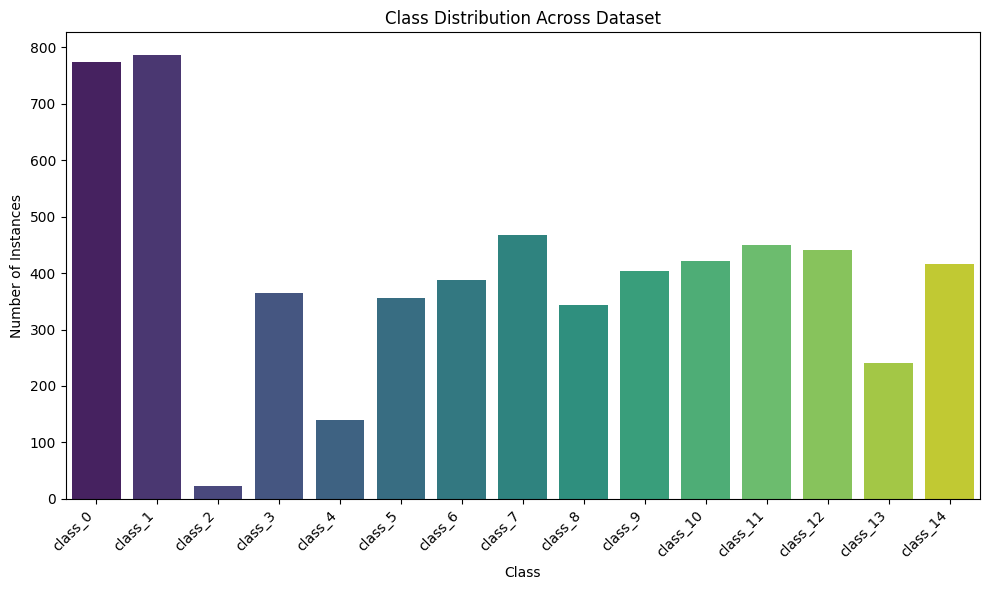

0     774
1     787
2      22
3     365
4     139
5     356
6     387
7     468
8     343
9     404
10    422
11    449
12    440
13    240
14    416
Name: count, dtype: int64


In [25]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Class Distribution Chart ---

print("\n--- Analyzing Class Distribution ---")

all_class_ids = []

# Collect class IDs from all label files (train, val, test)
for label_dir in [LAB_TRAIN_DIR, LAB_VAL_DIR, LAB_TEST_DIR]:
    if not os.path.exists(label_dir):
        print(f"Warning: Label directory not found for class distribution: {label_dir}")
        continue
    for filename in os.listdir(label_dir):
        if filename.endswith('.txt'):
            file_path = os.path.join(label_dir, filename)
            with open(file_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        try:
                            class_id = int(parts[0])
                            all_class_ids.append(class_id)
                        except ValueError:
                            pass # Handled during annotation validation

if not all_class_ids:
    print("No class IDs found for distribution analysis. Please ensure label files are correctly populated.")
else:
    class_counts = pd.Series(all_class_ids).value_counts().sort_index()

    # Get class names from data.yaml if available, otherwise use generic
    if 'names' in data_yaml_content and data_yaml_content['names']:
        class_names = {i: name for i, name in enumerate(data_yaml_content['names'])}
        labels = [class_names.get(i, f'class_{i}') for i in class_counts.index]
    else:
        labels = [f'class_{i}' for i in class_counts.index]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=labels, y=class_counts.values, palette='viridis')
    plt.title('Class Distribution Across Dataset')
    plt.xlabel('Class')
    plt.ylabel('Number of Instances')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    print(class_counts)



--- Analyzing Image Resolutions ---


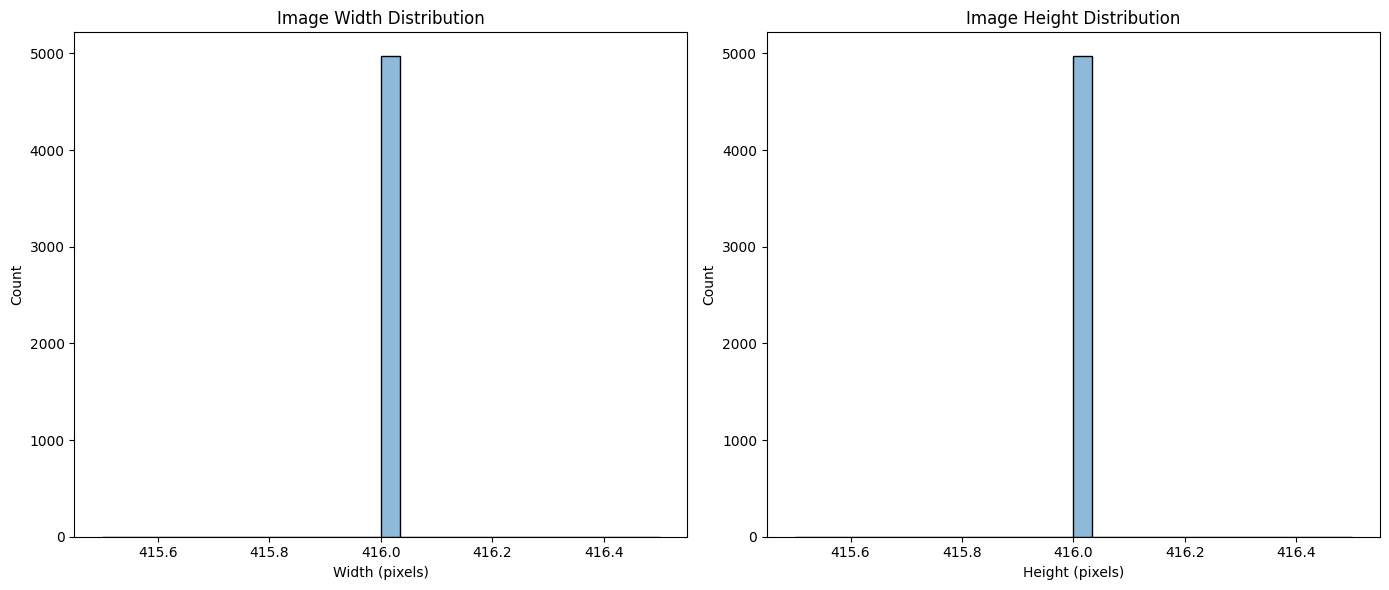


Summary of Image Widths: Min=416, Max=416, Mean=416.00
Summary of Image Heights: Min=416, Max=416, Mean=416.00


In [26]:
from PIL import Image
import numpy as np

# --- 2. Resolution Histogram ---

print("\n--- Analyzing Image Resolutions ---")

all_widths = []
all_heights = []

# Collect image paths from all image directories
image_dirs = [IMG_TRAIN_DIR, IMG_VAL_DIR, IMG_TEST_DIR]
all_image_file_paths = []
for img_dir in image_dirs:
    if not os.path.exists(img_dir):
        print(f"Warning: Image directory not found for resolution analysis: {img_dir}")
        continue
    for filename in os.listdir(img_dir):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_image_file_paths.append(os.path.join(img_dir, filename))

if not all_image_file_paths:
    print("No image files found for resolution analysis.")
else:
    for img_path in all_image_file_paths:
        try:
            with Image.open(img_path) as img:
                width, height = img.size
                all_widths.append(width)
                all_heights.append(height)
        except Exception as e:
            print(f"Could not read image {img_path}: {e}")

    if all_widths and all_heights:
        plt.figure(figsize=(14, 6))

        plt.subplot(1, 2, 1)
        sns.histplot(all_widths, bins=30, kde=True)
        plt.title('Image Width Distribution')
        plt.xlabel('Width (pixels)')
        plt.ylabel('Count')

        plt.subplot(1, 2, 2)
        sns.histplot(all_heights, bins=30, kde=True)
        plt.title('Image Height Distribution')
        plt.xlabel('Height (pixels)')
        plt.ylabel('Count')

        plt.tight_layout()
        plt.show()

        print(f"\nSummary of Image Widths: Min={np.min(all_widths)}, Max={np.max(all_widths)}, Mean={np.mean(all_widths):.2f}")
        print(f"Summary of Image Heights: Min={np.min(all_heights)}, Max={np.max(all_heights)}, Mean={np.mean(all_heights):.2f}")
    else:
        print("No image dimensions collected for plotting.")


--- Visualizing Sample Images with Annotations ---


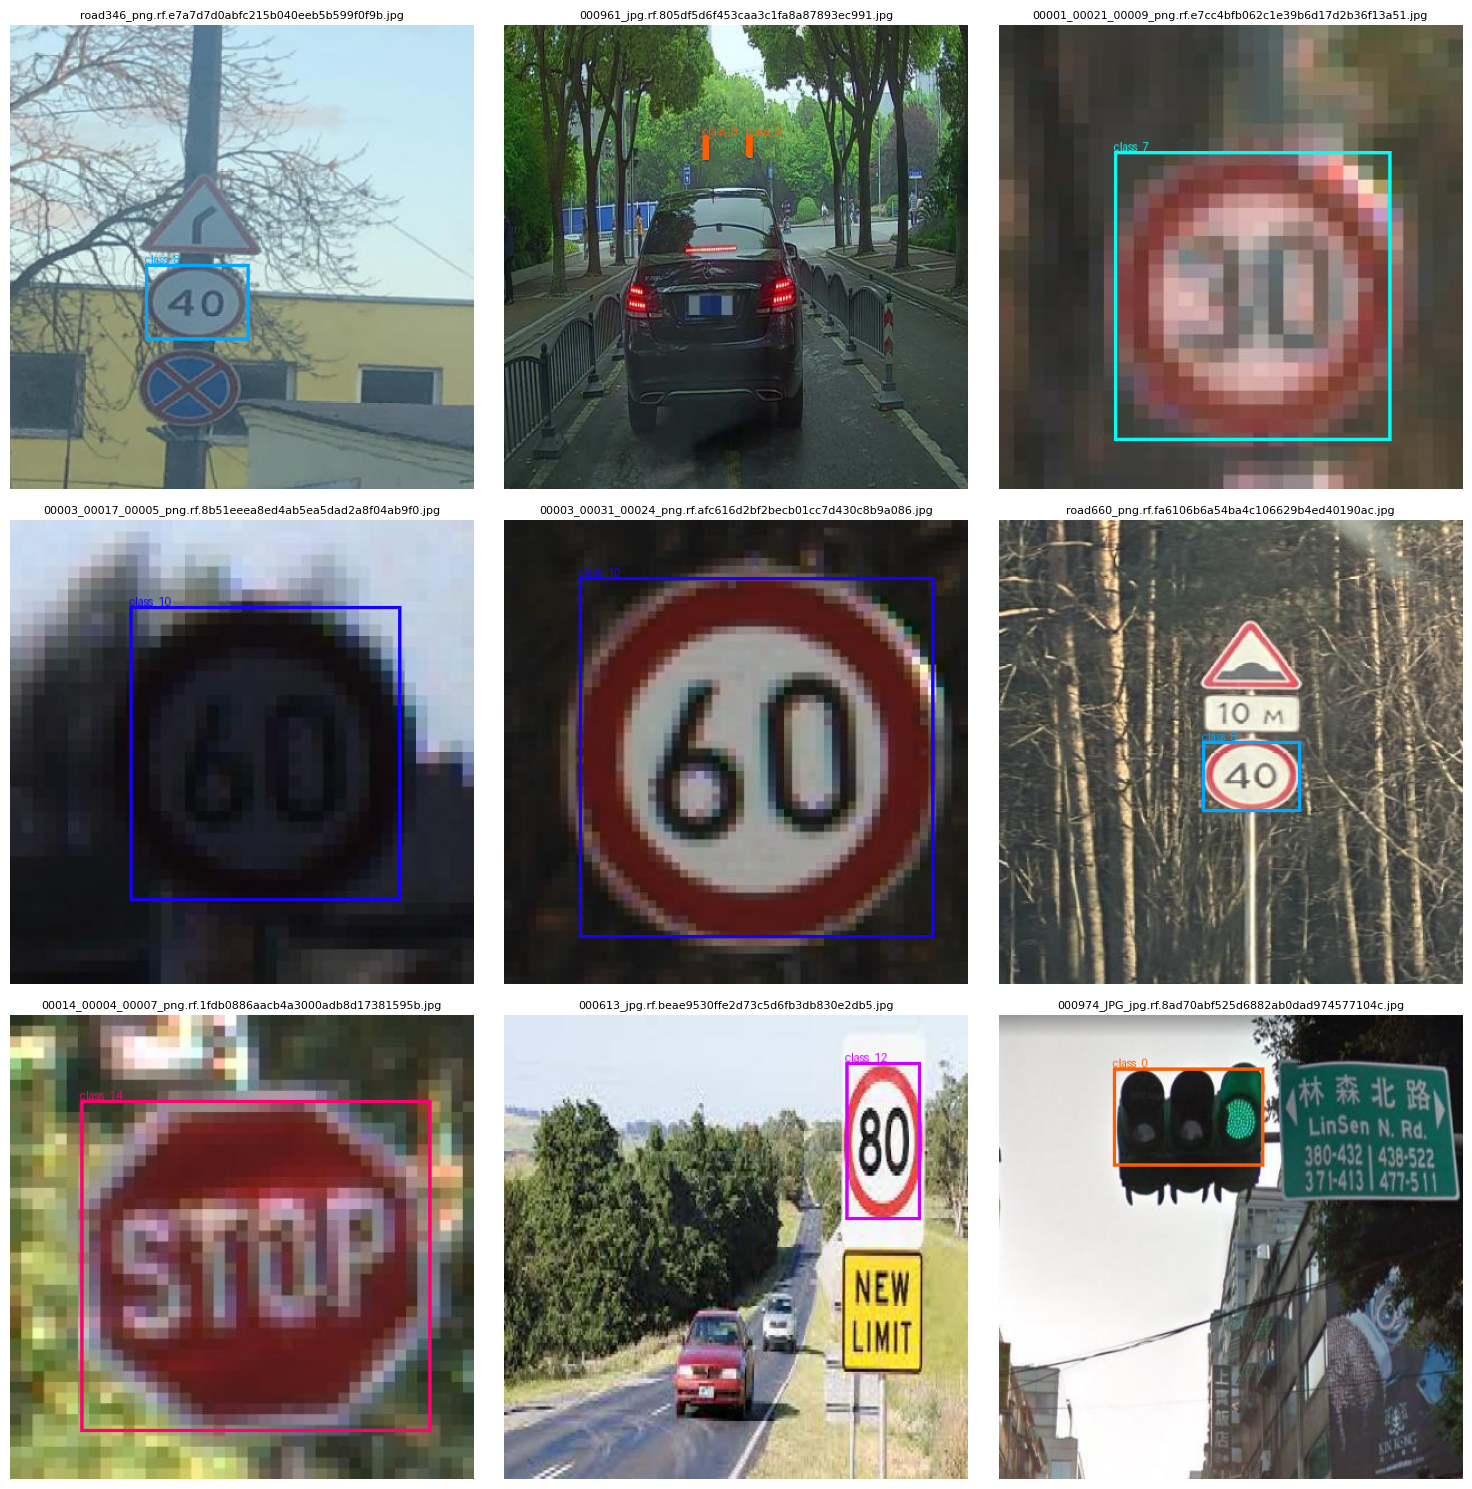

In [27]:
import random
from PIL import Image, ImageDraw

# --- 3. Sample Grid Visualization ---

print("\n--- Visualizing Sample Images with Annotations ---")

def plot_image_with_bboxes(ax, image_path, label_path, class_names):
    try:
        img = Image.open(image_path).convert("RGB")
        draw = ImageDraw.Draw(img)
        img_width, img_height = img.size

        # Colors for bounding boxes (can be expanded)
        colors = sns.color_palette('hsv', len(class_names)) # Use 'hsv' for distinct colors

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        class_id = int(parts[0])
                        cx, cy, w, h = map(float, parts[1:])

                        # Convert normalized YOLO format to pixel coordinates (x_min, y_min, x_max, y_max)
                        x_center = cx * img_width
                        y_center = cy * img_height
                        box_width = w * img_width
                        box_height = h * img_height

                        x_min = int(x_center - box_width / 2)
                        y_min = int(y_center - box_height / 2)
                        x_max = int(x_center + box_width / 2)
                        y_max = int(y_center + box_height / 2)

                        # Draw bounding box
                        color = tuple(int(c * 255) for c in colors[class_id % len(colors)])
                        draw.rectangle([x_min, y_min, x_max, y_max], outline=color, width=3)

                        # Draw class label
                        label_text = class_names.get(class_id, f'class_{class_id}')
                        # Adjust text position to be above the box
                        text_position = (x_min, y_min - 10 if y_min - 10 > 0 else y_min + 5)
                        draw.text(text_position, label_text, fill=color)
        else:
            ax.set_title("No Label File")

        ax.imshow(img)
        ax.axis('off')
        ax.set_title(os.path.basename(image_path), fontsize=8)
    except Exception as e:
        print(f"Error plotting image {image_path}: {e}")
        ax.set_title(f"Error: {os.path.basename(image_path)}")
        ax.axis('off')

# Number of samples to visualize
num_samples_to_show = 9 # For a 3x3 grid

# Get a random selection of image-label pairs from the training set
if len(train_images) == 0:
    print("No training images available for visualization. Skipping sample grid visualization.")
elif len(train_images) < num_samples_to_show:
    sample_indices = list(range(len(train_images)))
    print(f"Warning: Only {len(train_images)} training images available, showing all.")
else:
    sample_indices = random.sample(range(len(train_images)), num_samples_to_show)

# Construct new paths for the samples using the organized dataset structure
new_sample_image_paths = []
new_sample_label_paths = []

for i in sample_indices:
    original_image_path = train_images[i]
    original_label_path = train_labels[i]

    image_basename = os.path.basename(original_image_path)
    label_basename = os.path.basename(original_label_path)

    new_sample_image_paths.append(os.path.join(IMG_TRAIN_DIR, image_basename))
    new_sample_label_paths.append(os.path.join(LAB_TRAIN_DIR, label_basename))

sample_image_paths = new_sample_image_paths
sample_label_paths = new_sample_label_paths

# Prepare class names for plotting
class_names_for_plot = {i: name for i, name in enumerate(data_yaml_content.get('names', []))}

if sample_image_paths:
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.flatten()

    for i, (img_path, lab_path) in enumerate(zip(sample_image_paths, sample_label_paths)):
        plot_image_with_bboxes(axes[i], img_path, lab_path, class_names_for_plot)

    plt.tight_layout()
    plt.show()
else:
    print("No sample images selected for visualization.")

## **Install the Ultralytics framework**

In [28]:
 pip install ultralytics

Note: you may need to restart the kernel to use updated packages.


## Load YOLOv8 Model

We will load a pre-trained YOLOv8 model. You can choose between different sizes like `yolov8n.pt` (nano), `yolov8s.pt` (small), `yolov8m.pt` (medium), `yolov8l.pt` (large), or `yolov8x.pt` (extra large), depending on your needs for speed and accuracy.

For this example, we'll start with `yolov8n.pt` (nano) to demonstrate transfer learning. This model is lightweight and serves as a good starting point for fine-tuning on custom datasets, as it already has learned robust features from a large dataset like COCO.

In [29]:
from ultralytics import YOLO

# Load a pre-trained YOLOv8n model (COCO weights) for transfer learning
model = YOLO('yolov8n.pt') # You can change this to yolov8s.pt, yolov8m.pt, etc.

## Train YOLOv8 Model with Specific Hyperparameters

Now, let's train the YOLOv8 model on your custom car detection dataset using the specified hyperparameters. The `train` method will automatically configure the model's last layer to match the number of classes specified in the `data.yaml` file.

**Key arguments for training:**
- `data`: Path to your `data.yaml` configuration file.
- `epochs`: Number of training epochs (set to 100).
- `imgsz`: Input image size (set to 640x640).
- `batch`: Batch size for training (set to 8).
- `lr0`: Initial learning rate (set to 0.01).
- `cos_lr`: Use a cosine learning rate scheduler.
- `optimizer`: Optimization algorithm (set to 'SGD').
- `momentum`: Momentum for SGD optimizer (set to 0.937).
- `weight_decay`: Weight decay for optimizer (set to 0.0005).
- `augment`: Enable data augmentation for techniques like mosaic, random flip, HSV adjustments.
- `name`: A name for the training run, useful for organizing results.

In [30]:
# Define data_yaml_path explicitly to ensure it's in scope
data_yaml_path = 'dataset/data.yaml'

# Train the model with specified hyperparameters
# The number of classes (nc) in data.yaml will automatically be used to adjust the detection head.
results = model.train(
    data=data_yaml_path,        # Path to your data.yaml
    epochs=100,                 # Number of training epochs
    imgsz=640,                  # Input image size 640x640
    batch=8,                    # Batch size
    lr0=0.01,                   # Initial learning rate
    cos_lr=True,                # Use cosine learning rate schedule
    optimizer='SGD',            # Optimizer
    momentum=0.937,             # Momentum for SGD
    weight_decay=0.0005,        # Weight decay
    augment=True,               # Enable data augmentation (includes mosaic, random horizontal flip, HSV)
    flipud=0.5,                 # Enable random vertical flip
    name='yolov8n_custom_car_detection_hyperparams' # Unique name for this run
)

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_custom_car_detection_hyperparams-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_ma

## Model Evaluation

After training, it's crucial to evaluate the model's performance on the held-out test set. The `model.val()` method in Ultralytics will perform this evaluation, computing key metrics and generating useful visualization plots.

**Evaluation will cover:**
- Running inference on the test set.
- Generating a confusion matrix.
- Generating Precision-Recall (PR) curves.
- Generating F1-confidence curves.
- Computing mean Average Precision (mAP) at various Intersection over Union (IoU) thresholds, specifically mAP@0.5 and mAP@0.5:0.95.
- Providing per-class accuracy to identify categories where the model might be underperforming.
- Reporting inference speed (FPS) on the current hardware (CPU in this Colab environment).

The results, including plots, will be saved in the `runs/detect/` directory under your training run name.

In [31]:
# Validate the model on the test set
# This will generate metrics and plots like confusion matrix, PR curve, F1-confidence curve
metrics = model.val(split='test', plots=True)

# Print key metrics
print(f"mAP@0.5: {metrics.results_dict['metrics/mAP50(B)']:.3f}")
print(f"mAP@0.5:0.95: {metrics.results_dict['metrics/mAP50-95(B)']:.3f}")

# You can access per-class metrics if needed (e.g., precision, recall, F1-score for each class)
# For example, to get per-class P, R, mAP50, mAP50-95, you can inspect `metrics.p`, `metrics.r`, `metrics.map50`, `metrics.map`

# The plots (confusion_matrix.png, P_curve.png, R_curve.png, F1_curve.png) will be saved in the run directory.

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 555.3±309.5 MB/s, size: 18.5 KB)
val: Scanning /kaggle/working/dataset/labels/test... 497 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 497/497 1.4Kit/s 0.4s<0.1s
val: New cache created: /kaggle/working/dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 6.8it/s 4.7s0.1s
                   all        497        592      0.887      0.861      0.919      0.784
               class_0         52         74      0.876      0.861      0.898      0.542
               class_1         51         71      0.725      0.746      0.756      0.431
               class_2          2          3      0.493      0.333      0.463       0.41
               class_3         41         41      0.958          

## **Real-time Inference Demo**

Now, let's demonstrate the trained model's capability for real-time inference on a video. We'll use the `video.mp4` file from your `cardetection_dataset` to simulate real-world conditions.

The `model.predict()` method of the Ultralytics YOLO model is designed for this. It will automatically:
- Process each frame of the input video.
- Detect objects (car signs in this case).
- Render bounding boxes, class labels, and confidence scores on the detected objects.
- Save the annotated frames as a new video file.

This generated video will serve as a demo output in the submission notebook.

In [32]:
import os

# Define the path to the input video
video_path = 'cardetection_dataset/video.mp4'

# Define the output directory for the inference results
output_dir = 'runs/predict_video'
os.makedirs(output_dir, exist_ok=True)

# Perform inference on the video
# The 'save=True' argument ensures the annotated video is saved.
# The 'show=False' argument prevents displaying the video during Colab execution.
results = model.predict(
    source=video_path, 
    save=True, 
    imgsz=640, 
    conf=0.25,  # Confidence threshold
    iou=0.7,    # IoU threshold for NMS
    project='runs', # Project directory for saving results
    name='predict_video' # Name of the experiment
)

print(f"Inference complete. Annotated video saved in the directory: {os.path.join('runs', 'predict_video')}")
print("You can find the processed video (e.g., video.avi or video.mp4) inside this folder.")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/508) /kaggle/working/cardetection_dataset/video.mp4: 640x640 1 class_14, 7.2ms
video 1/1 (frame 2/508) /kaggle/working/cardetection_dataset/video.mp4: 640x640 1 class_14, 7.2ms
video 1/1 (frame 3/508) /kaggle/working/cardetection_dataset/video.mp4: 640x640 1 class_14, 7.2ms
video 1/1 (frame 4/508) /kaggle/working/cardetection_dataset/video.mp4: 640x640 (no detections), 7.2ms
video 1/1 (frame 5/508) /kaggle/working/cardetection_dataset/

## **Download best YOLO weights**

In [33]:
import shutil
import os

# Define the path to the best weights file from the training run
# Assuming the training run named 'yolov8n_custom_car_detection_hyperparams' is in 'runs/detect'
source_weights_path = 'runs/detect/yolov8n_custom_car_detection_hyperparams/weights/best.pt'

# Define the destination path in the current working directory
destination_weights_path = 'best.pt'

# Copy the file
if os.path.exists(source_weights_path):
    shutil.copy(source_weights_path, destination_weights_path)
    print(f"Successfully copied '{source_weights_path}' to '{destination_weights_path}'")
    print("You can now download 'best.pt' from your Kaggle files sidebar.")
else:
    print(f"Error: Best weights file not found at '{source_weights_path}'.")
    print("Please ensure the training completed successfully and check the run directory name.")

Successfully copied 'runs/detect/yolov8n_custom_car_detection_hyperparams/weights/best.pt' to 'best.pt'
You can now download 'best.pt' from your Kaggle files sidebar.


### **Benchmarking on Raspberry Pi**

To benchmark inference speed (FPS) on Raspberry Pi hardware, you first need to export the trained YOLOv8 model to a format optimized for embedded devices, such as ONNX or TFLite. Once exported, you would transfer the model to your Raspberry Pi and use appropriate inference engines (e.g., OpenCV's DNN module for ONNX, or TensorFlow Lite interpreter for TFLite) to run predictions and measure FPS.

Here's how you can export your trained model to ONNX:

In [34]:
# Export the trained model to ONNX format
# This creates an 'yolov8n_custom_car_detection_hyperparams.onnx' file in your runs directory
success = model.export(format='onnx', img_size=640)

print(f"Model exported to ONNX: {success}")
print("You can now download the .onnx file from the runs directory and use it on your Raspberry Pi.")

# For TFLite export (if needed, consider quantization for even smaller size/faster inference on edge devices)
# success_tflite = model.export(format='tflite', img_size=640, int8=True) # int8=True for post-training quantization
# print(f"Model exported to TFLite: {success_tflite}")

SyntaxError: '[31m[1mimg_size[0m' is not a valid YOLO argument. Similar arguments are i.e. ['imgsz=640', 'optimize=False'].

    Arguments received: ['yolo', '-f', '/root/.local/share/jupyter/runtime/kernel-0f5f81ce-e84b-42df-8a18-4f730983dd2c.json']. Ultralytics 'yolo' commands use the following syntax:

        yolo TASK MODE ARGS

        Where   TASK (optional) is one of ['classify', 'obb', 'semantic', 'detect', 'segment', 'pose']
                MODE (required) is one of ['track', 'export', 'train', 'val', 'benchmark', 'predict']
                ARGS (optional) are any number of custom 'arg=value' pairs like 'imgsz=320' that override defaults.
                    See all ARGS at https://docs.ultralytics.com/usage/cfg or with 'yolo cfg'

    1. Train a detection model for 10 epochs with an initial learning_rate of 0.01
        yolo train data=coco8.yaml model=yolo26n.pt epochs=10 lr0=0.01

    2. Predict a YouTube video using a pretrained segmentation model at image size 320:
  